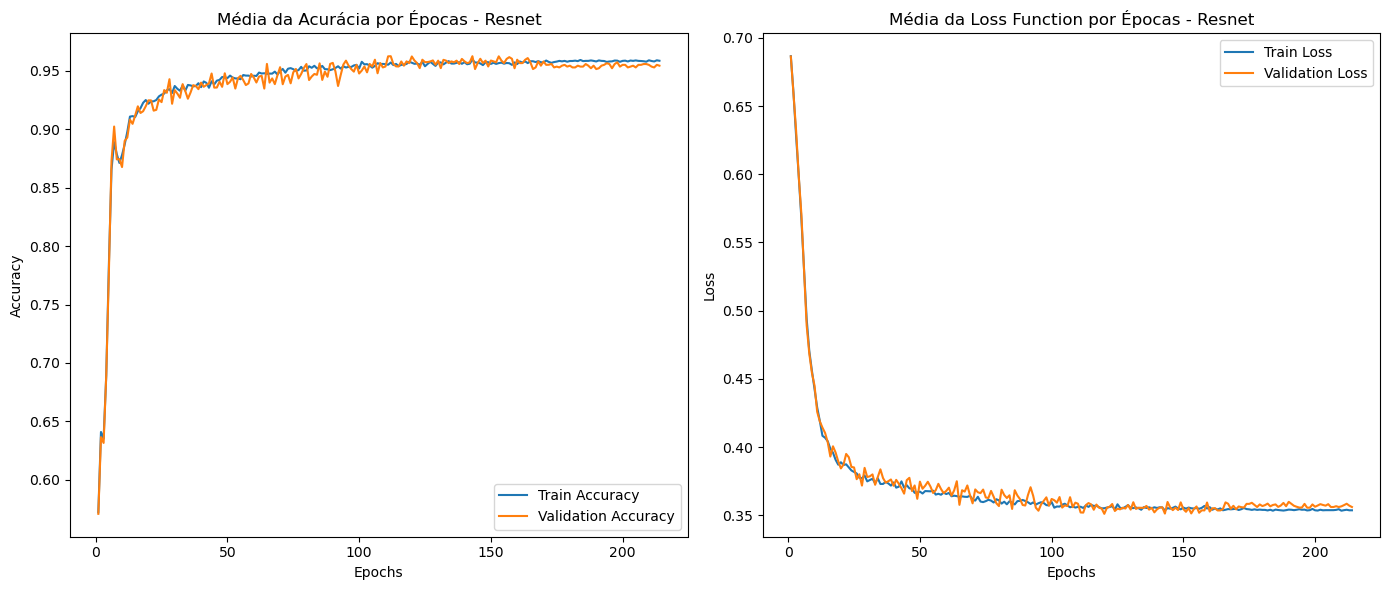

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt


folds_data = {}

regex_training = r"Fold (\d+) - Epoch (\d+) - Training Accuracy: ([\d.]+), Loss: ([\d.]+)"
regex_validation = r"Fold (\d+) - Epoch: (\d+) - Validation Accuracy: ([\d.]+), Loss: ([\d.]+)"


with open('logs_resnet.txt', 'r') as file:
    for line in file:
        
        # search para training
        training = re.search(regex_training, line)
        # search para o validation
        validation = re.search(regex_validation, line)
        
        if training:
            fold = int(training.group(1))
            epoch = int(training.group(2))
            train_accuracy = float(training.group(3))
            train_loss = float(training.group(4))
            
            # inicializa o fold no dicionário, caso seja necessário
            if fold not in folds_data:
                folds_data[fold] = {
                    "train_accuracy": [],
                    "train_loss": [],
                    "val_accuracy": [],
                    "val_loss": [],
                    "epochs": [],
                }
            
            # adicionando os valores de treino ao dicionário
            folds_data[fold]["train_accuracy"].append(train_accuracy)
            folds_data[fold]["train_loss"].append(train_loss)
            folds_data[fold]["epochs"].append(epoch)
        
        elif validation:
            fold = int(validation.group(1))
            val_accuracy = float(validation.group(3))
            val_loss = float(validation.group(4))
            
            # adicionando os valores de validação ao dicionário
            folds_data[fold]["val_accuracy"].append(val_accuracy)
            folds_data[fold]["val_loss"].append(val_loss)


# Passo 1: Encontrar o número máximo de épocas entre todos os folds
max_epochs = max(len(fold_data["epochs"]) for fold_data in folds_data.values())

# Passo 2: Preencher os valores faltantes com o último valor disponível
for fold_data in folds_data.values():
    for key in ["train_accuracy", "train_loss", "val_accuracy", "val_loss"]:
        last_value = fold_data[key][-1]  # Último valor disponível
        fold_data[key] += [last_value] * (max_epochs - len(fold_data[key]))

# Passo 3: Calcular as médias para cada época
avg_train_accuracy = np.mean([fold_data["train_accuracy"] for fold_data in folds_data.values()], axis=0)
avg_train_loss = np.mean([fold_data["train_loss"] for fold_data in folds_data.values()], axis=0)
avg_val_accuracy = np.mean([fold_data["val_accuracy"] for fold_data in folds_data.values()], axis=0)
avg_val_loss = np.mean([fold_data["val_loss"] for fold_data in folds_data.values()], axis=0)


epochs = range(1, max_epochs + 1)
plt.figure(figsize=(14, 6))

# Gráfico da Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs, avg_train_accuracy, label="Train Accuracy")
plt.plot(epochs, avg_val_accuracy, label="Validation Accuracy")
plt.title("Média da Acurácia por Épocas - Resnet")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Gráfico da Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, avg_train_loss, label="Train Loss")
plt.plot(epochs, avg_val_loss, label="Validation Loss")
plt.title("Média da Loss Function por Épocas - Resnet")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()